# Deep learning applied to gravitational lensing

## Import parameters

In [1]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

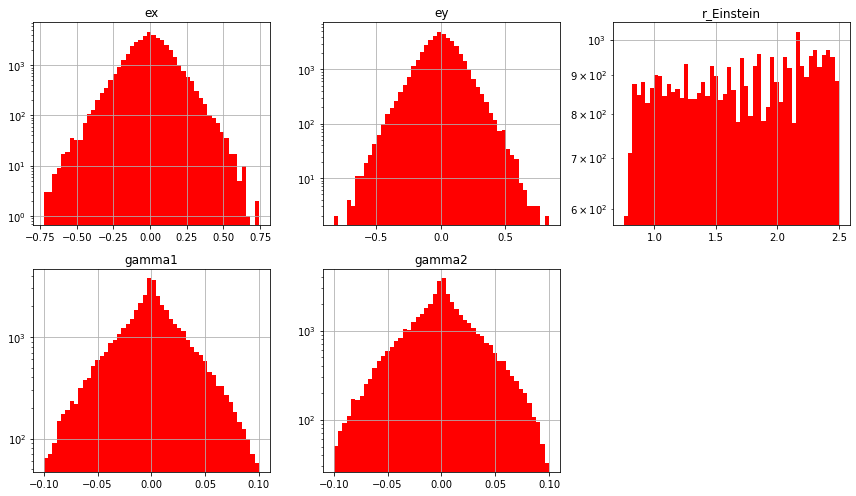

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, color='red', alpha=1, log=True)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.show()

## Images

In [6]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [10]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [11]:
import os
os.chdir("/home/mbatt")

In [12]:
image_index = 9

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


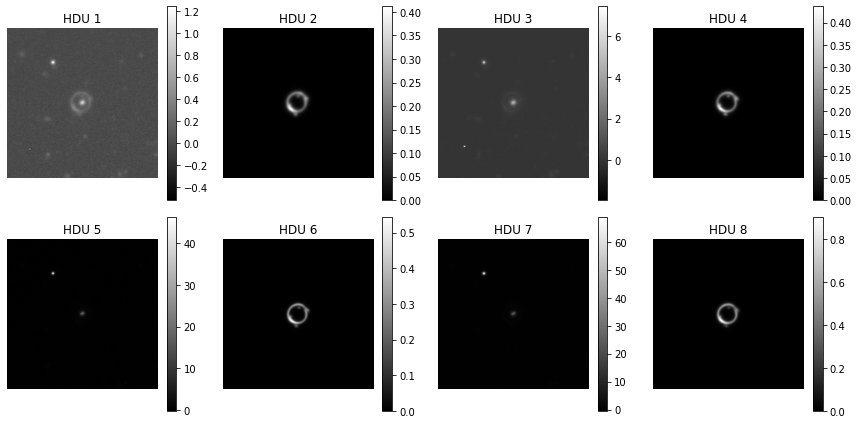

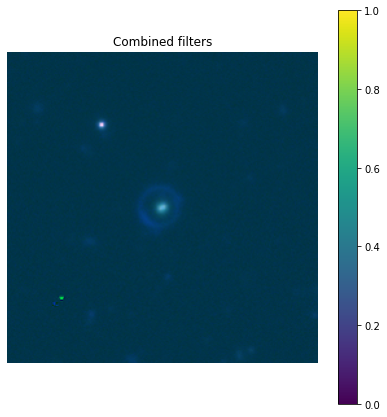

In [13]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [14]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 4 
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [15]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [16]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location):
#     if ima_file.split('/')[1] + '.pt' not in LL:
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul), 2)]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12_source_1225_r_0.fits.pt


/tmp/ipykernel_16321/1475162526.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)


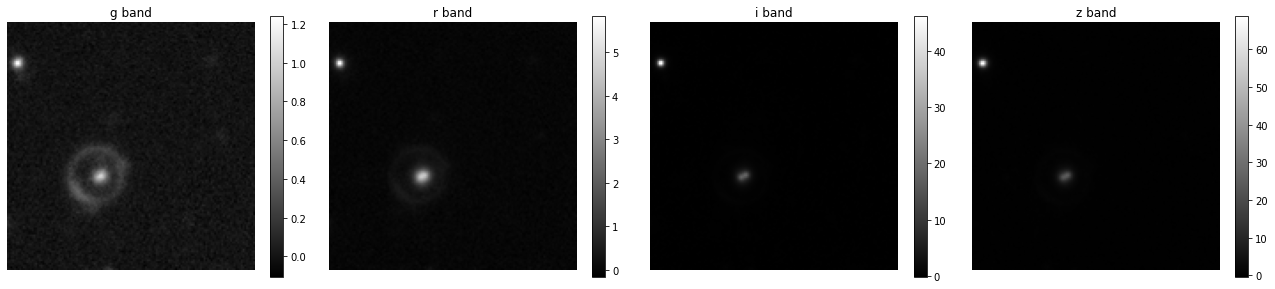

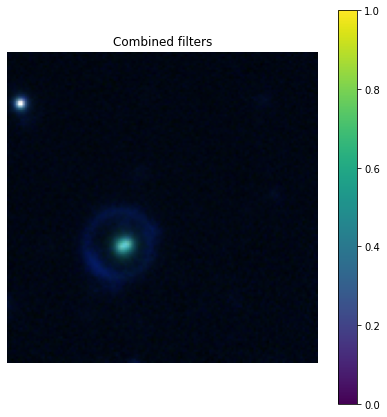

In [17]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# Deep learning models

In [18]:
df_sample

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,1.110223e-16,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [19]:

dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [20]:
# cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
# dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [21]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']

means = dff[cols_to_norm].mean()
stds = dff[cols_to_norm].std()

dff[cols_to_norm] = (dff[cols_to_norm] - means) / stds

In [22]:
dff = dff.sample(frac=1, random_state=42)

In [23]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [24]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

## Load data

In [25]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [26]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

## Import Models

In [27]:
from deep_learning_models import ResNetHoliSmokes
from deep_learning_models import ResNetMini

In [28]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [29]:
# model = ResNetMini()   
# model = ResNetHoliSmokes()
model = BayesianResNetMini()

In [30]:
v = viewer(model)
v.show_model()
# Image("resnetmini.png")

In [31]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [32]:
Train_model = Trainer(model = model,
                      learning_rate = 1e-5,
                      scheduler_coef = 0.1                  
)

In [33]:
Train_model.run_bayes(epochs = 60,
                training_set = train_loader, 
                validation_set = val_loader,
                kl_weight = 1e-3, # Weights for the kullback-Leibler divergence
               MC_samples = 30 # Number of samples to estimate the epistemic uncertainty
                     )

KeyboardInterrupt: 

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load(f"{model.model_name}_3.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


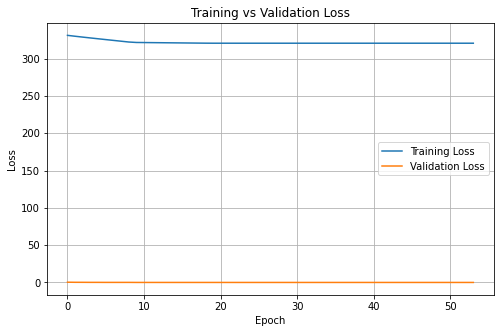

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses[1:], label="Training Loss")
plt.plot(val_losses[1:], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [36]:
model.eval()
MC_samples = 30
all_mu = []
all_y = []

all_epistemic = []
all_aleatoric = []
all_total_std = []

test_loss = 0.0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # ---- deterministic CNN backbone (computed once) ----
        features = model.forward_features(xb)

        mus = []
        sigmas = []

        # ---- MC sampling over Bayesian head ----
        for _ in range(MC_samples):
            mu, sigma, _ = model.forward_head(features)
            mus.append(mu)
            sigmas.append(sigma)

        mus = torch.stack(mus)         # [MC, batch, dim]
        sigmas = torch.stack(sigmas)   # [MC, batch, dim]
        
        # ---- predictive mean ----
        mu_mean = mus.mean(dim=0)

        # ---- uncertainty decomposition ----
        epistemic_var = mus.var(dim=0)
        aleatoric_var = (sigmas ** 2).mean(dim=0)
        total_var = epistemic_var + aleatoric_var
        total_std = torch.sqrt(total_var)

        # ---- NLL loss (optional monitoring) ----
        nll = ((mus - yb)**2 / (2 * sigmas**2) + torch.log(sigmas**2)).mean()
        test_loss += nll.item()

        # ---- store results ----
        all_mu.append(mu_mean.cpu())
        all_y.append(yb.cpu())

        all_epistemic.append(epistemic_var.cpu())
        all_aleatoric.append(aleatoric_var.cpu())
        all_total_std.append(total_std.cpu())

# ---- concatenate full test set ----
all_mu = torch.cat(all_mu, dim=0)
all_y = torch.cat(all_y, dim=0)

all_epistemic = torch.cat(all_epistemic, dim=0)
all_aleatoric = torch.cat(all_aleatoric, dim=0)
all_total_std = torch.cat(all_total_std, dim=0)

test_loss /= len(test_loader)

print(f"Test NLL: {test_loss:.4f}")

Test NLL: -0.3388


In [37]:
mus[:,0,0].var(dim=0)

tensor(0.0015, device='cuda:0')

In [38]:
mus[:,0,0].mean()

tensor(-0.5983, device='cuda:0')

In [39]:
((mus[:,0,0] - mus[:,0,0].mean())**2).mean().sqrt()

tensor(0.0384, device='cuda:0')

In [40]:
model.fcb.weight_mu

Parameter containing:
tensor([[-7.4861e-02,  2.0560e-02,  1.5893e-03,  ..., -1.8212e-03,
          1.2804e-06,  2.9357e-02],
        [ 8.2177e-02,  3.2425e-03,  1.0646e-01,  ...,  4.5138e-02,
         -1.0934e-06,  4.4601e-02],
        [-1.6566e-01,  2.2910e-02, -1.2851e-02,  ..., -9.0172e-02,
         -1.6674e-01, -1.6596e-01],
        ...,
        [-1.0249e-01, -3.3484e-02,  1.8310e-02,  ..., -5.7918e-03,
          4.7733e-05,  7.9626e-03],
        [-2.9298e-02,  9.4026e-02, -8.5683e-02,  ..., -2.2715e-02,
         -1.4213e-01,  5.8329e-02],
        [-5.7874e-02, -6.8499e-02,  3.5414e-03,  ..., -6.1501e-02,
         -5.0672e-06, -1.1844e-01]], device='cuda:0', requires_grad=True)

In [41]:
# model.fcb.weight_rho
torch.log1p(torch.exp(model.fcb.weight_rho))

tensor([[0.0450, 0.0415, 0.0548,  ..., 0.0506, 0.0522, 0.0527],
        [0.0508, 0.0665, 0.0512,  ..., 0.0471, 0.0477, 0.0524],
        [0.0488, 0.0620, 0.0639,  ..., 0.0498, 0.0599, 0.0484],
        ...,
        [0.0514, 0.0455, 0.0513,  ..., 0.0568, 0.0490, 0.0510],
        [0.0537, 0.0467, 0.0606,  ..., 0.0509, 0.0500, 0.0552],
        [0.0481, 0.0520, 0.0566,  ..., 0.0642, 0.0496, 0.0549]],
       device='cuda:0', grad_fn=<Log1PBackward0>)

In [42]:
epistemic_var

tensor([[0.0015, 0.0008, 0.0011, 0.0028, 0.0020],
        [0.0048, 0.0024, 0.0023, 0.0067, 0.0050],
        [0.0015, 0.0009, 0.0011, 0.0022, 0.0038],
        [0.0106, 0.0037, 0.0028, 0.0086, 0.0065],
        [0.0027, 0.0012, 0.0019, 0.0053, 0.0024],
        [0.0039, 0.0015, 0.0015, 0.0040, 0.0033],
        [0.0083, 0.0035, 0.0039, 0.0107, 0.0069],
        [0.0019, 0.0018, 0.0014, 0.0054, 0.0036],
        [0.0032, 0.0015, 0.0019, 0.0051, 0.0027],
        [0.0025, 0.0018, 0.0016, 0.0040, 0.0027]], device='cuda:0')

In [43]:
df_mean = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].mean().values
df_std  = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].std().values

y_true = all_y.numpy()
y_pred = all_mu.numpy()
all_epistemic = all_epistemic.numpy()
all_aleatoric = all_aleatoric.numpy()

# Means
y_true_denorm = y_true * df_std + df_mean
y_pred_denorm = y_pred * df_std + df_mean

# Uncertainty (std form)
epistemic_std = np.sqrt(all_epistemic) * df_std
aleatoric_std = np.sqrt(all_aleatoric) * df_std
total_std = np.sqrt(all_epistemic + all_aleatoric) * df_std

In [44]:
# # Min/max used for normalization
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # Convert to numpy
# y_true = all_y.numpy()
# y_pred = all_mu.numpy()
# all_epistemic = all_epistemic.numpy()
# all_aleatoric = all_aleatoric.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * (df_max - df_min) + df_min
# y_pred_denorm = y_pred * (df_max - df_min) + df_min

# # y_true_denorm = y_true 
# # y_pred_denorm = y_pred 

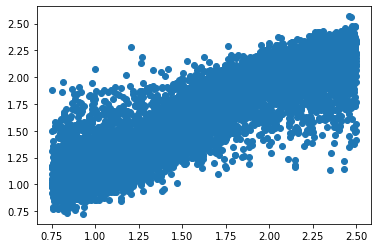

In [45]:
plt.scatter(y_true_denorm[:,0], y_pred_denorm[:,0])
plt.show()

In [46]:
all_epistemic[:10,4]

array([0.00867956, 0.0028756 , 0.00424717, 0.00411071, 0.00356689,
       0.00579471, 0.0035581 , 0.00773131, 0.00394641, 0.00423677],
      dtype=float32)

In [47]:
all_aleatoric[:10,]

array([[0.21672612, 0.9483808 , 0.93890566, 0.31768972, 0.25082618],
       [0.2275066 , 1.0312455 , 1.123043  , 0.20724444, 0.23593985],
       [0.20352508, 0.978732  , 0.9615608 , 0.23503675, 0.24558114],
       [0.17881934, 0.99980664, 1.0606339 , 0.18564385, 0.18848813],
       [0.625291  , 1.0616949 , 1.0910465 , 0.76008   , 0.84243387],
       [0.20328441, 0.96850085, 0.9658443 , 0.22630753, 0.22381148],
       [0.24618624, 0.9401466 , 0.9115091 , 0.25274995, 0.2459829 ],
       [0.2457588 , 1.0451723 , 1.079135  , 0.2883913 , 0.30929774],
       [0.19638236, 0.95152086, 0.97444046, 0.14128867, 0.17048636],
       [0.31621   , 0.945917  , 0.9772151 , 0.3440031 , 0.30181247]],
      dtype=float32)

In [48]:
y_pred_denorm[:10,0]

array([2.24244193, 1.2480607 , 1.09997156, 0.98752543, 1.72909936,
       1.03691738, 1.98934876, 1.231146  , 1.52565305, 1.91150177])

In [49]:
y_true_denorm[:10,0]

array([2.31794932, 0.76188979, 1.06082728, 0.90028572, 2.11330043,
       1.16319694, 2.15544687, 0.94936661, 1.97715907, 1.95198793])

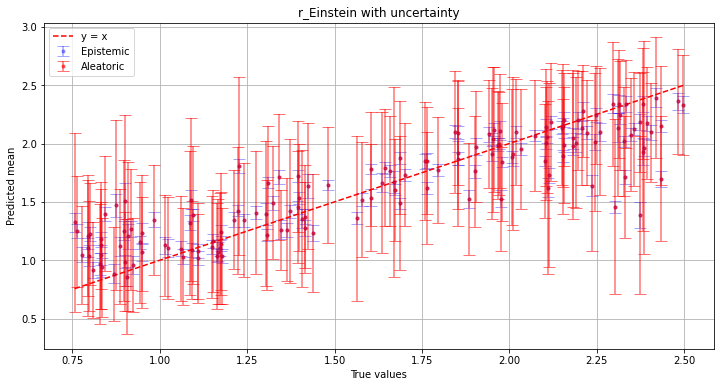

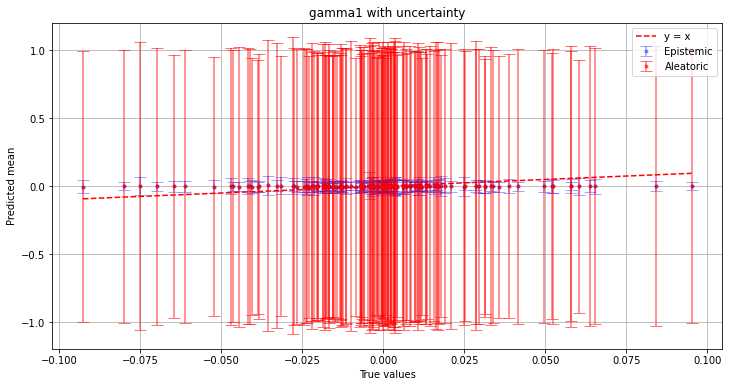

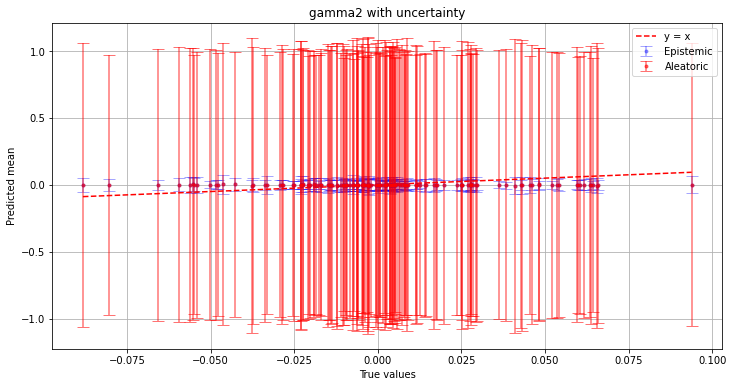

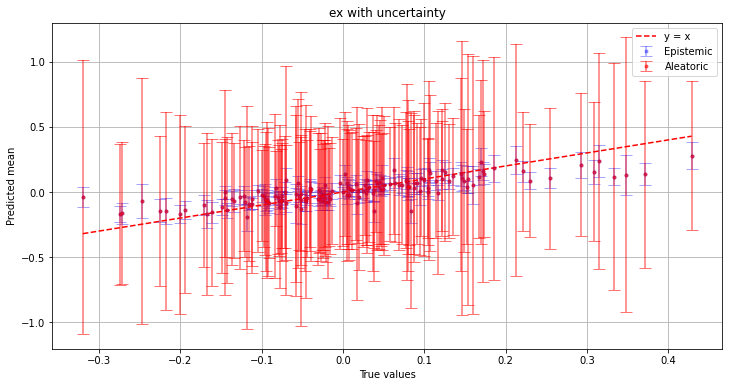

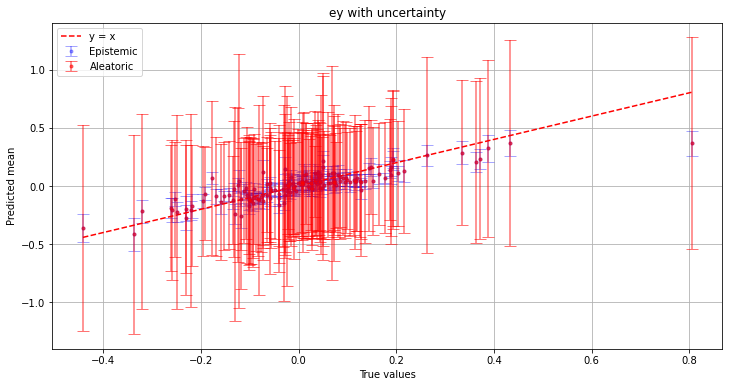

In [50]:
import numpy as np
import matplotlib.pyplot as plt

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]
V = 150
for i in range(5):
    true_values = y_true_denorm[:V,i]
    pred_mean = y_pred_denorm[:V,i]
    pred_epis = np.sqrt(all_epistemic[:V,i])
    pred_alea = np.sqrt(all_aleatoric[:V,i])

    plt.figure(figsize=(12,6))

    # Scatter points
#     plt.scatter(true_values, pred_mean, color='blue', alpha=0.7, label='Predictions')

    # Uncertainty bars (vertical)
    plt.errorbar(true_values, pred_mean, 
                 yerr=pred_epis, 
                 fmt='o', 
                 color='blue',
                 markersize=3,
                 alpha=0.35, 
                 ecolor='blue', 
                 capsize=6,
                label = 'Epistemic')
    
    plt.errorbar(true_values, pred_mean, 
                 yerr=pred_alea, 
                 fmt='o', 
                 color='red', 
                 markersize=3,
                 alpha=0.55, 
                 ecolor='red', 
                 capsize=6,
                label = 'Aleatoric')

    # Reference y=x line
    min_val = min(true_values.min(), pred_mean.min())
    max_val = max(true_values.max(), pred_mean.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

    plt.xlabel("True values")
    plt.ylabel("Predicted mean")
    plt.title(f"{param_names[i]} with uncertainty")
    plt.legend()
    plt.grid(True)
    plt.show()


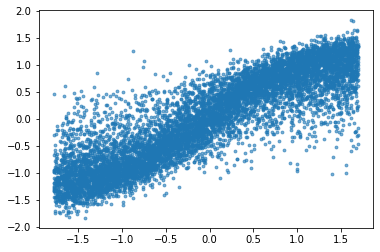

In [51]:
plt.scatter(all_y[:,0], all_mu[:,0], s=8, alpha=0.6)

plt.show()


Inside 1-sigma r_Einstein: 8560 / 8746  : 97.87%


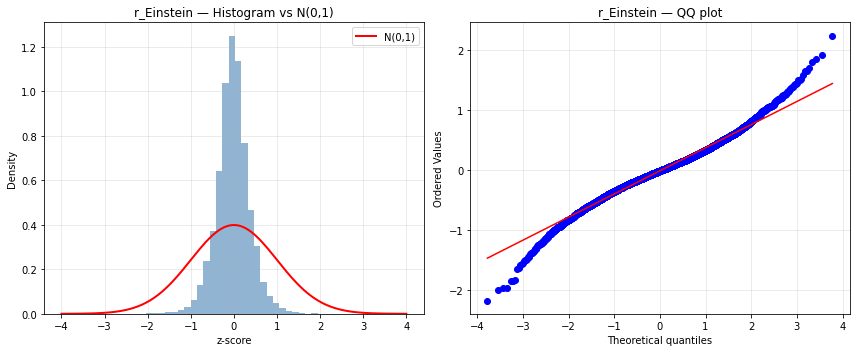

Inside 1-sigma gamma1: 8746 / 8746  : 100.00%


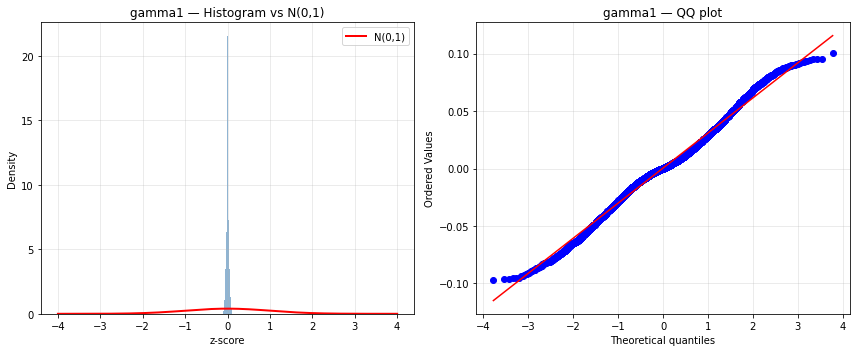

Inside 1-sigma gamma2: 8746 / 8746  : 100.00%


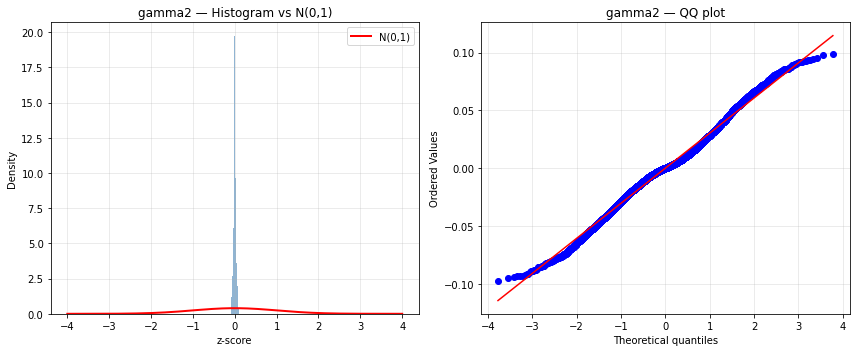

Inside 1-sigma ex: 8746 / 8746  : 100.00%


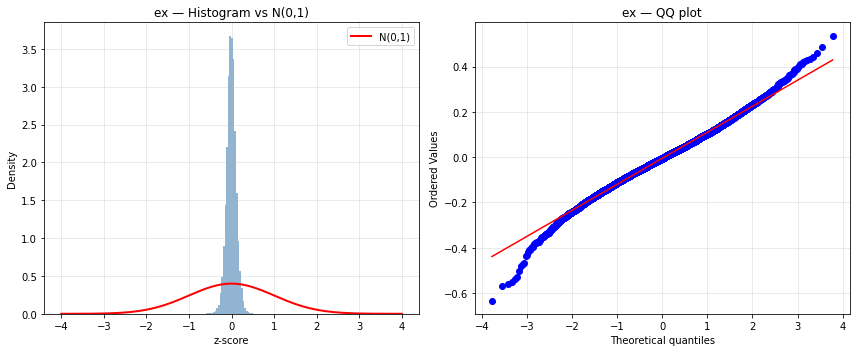

Inside 1-sigma ey: 8746 / 8746  : 100.00%


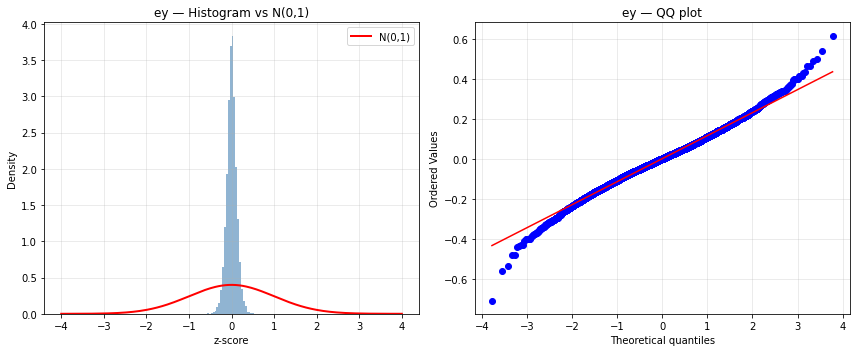

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

for i in range(5):

    true_values = y_true_denorm[:, i]
    pred_mean   = y_pred_denorm[:, i]
    pred_epis   = np.sqrt(all_epistemic[:, i])
    pred_alea   = np.sqrt(all_aleatoric[:, i])

    # Normalized residuals
    z = (true_values - pred_mean) / (pred_epis + pred_alea)
    # total predictive sigma
    sigma = pred_epis + pred_alea

    # boolean mask: true value inside [mean - sigma, mean + sigma]
    inside = (true_values >= pred_mean - sigma) & (true_values <= pred_mean + sigma)
    count_inside = inside.sum()
    count_total  = len(true_values)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # 1) Histogram + N(0,1) PDF
    # -------------------------
    ax[0].hist(z, bins=30, density=True, alpha=0.6, color="steelblue")

    # Standard normal PDF
    x = np.linspace(-4, 4, 200)
    ax[0].plot(x, stats.norm.pdf(x), color="red", lw=2, label="N(0,1)")

    ax[0].set_title(f"{param_names[i]} — Histogram vs N(0,1)")
    ax[0].set_xlabel("z-score")
    ax[0].set_ylabel("Density")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    

    # -------------------------
    # 2) QQ plot
    # -------------------------
    stats.probplot(z, dist="norm", plot=ax[1])
    ax[1].set_title(f"{param_names[i]} — QQ plot")
    ax[1].grid(True, alpha=0.3)
    
    print(f"Inside 1-sigma {param_names[i]}:", count_inside, "/", count_total, f" : {count_inside/count_total*100:.2f}%")

    plt.tight_layout()
    plt.show()


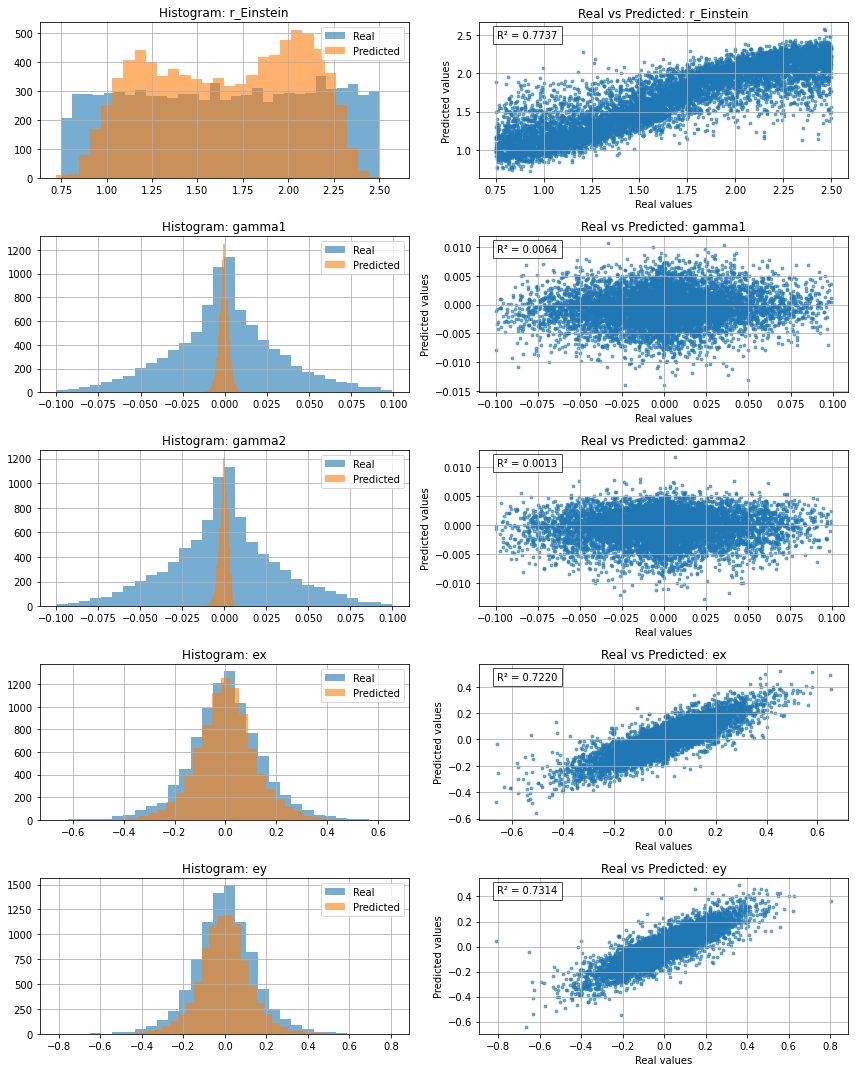

In [53]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(12, 15))

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Weierstrass distance (sup norm)
    weierstrass = np.max(np.abs(y_true_denorm[:, i] - y_pred_denorm[:, i]))

    # Histogram comparison
    plt.subplot(5, 2, 2*i + 1)
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted")
    plt.title(f"Histogram: {param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
    plt.subplot(5, 2, 2*i + 2)
    plt.scatter(y_true_denorm[:, i], y_pred_denorm[:, i], s=8, alpha=0.6)
    plt.xlabel("Real values")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted: {param_names[i]}")
    plt.grid(True)


    # Annotate metrics
    plt.text(
        0.05, 0.95,
        f"R² = {r2:.4f}",
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7)
    )

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ResNetHoliSmokes.png", dpi=300)
plt.show()


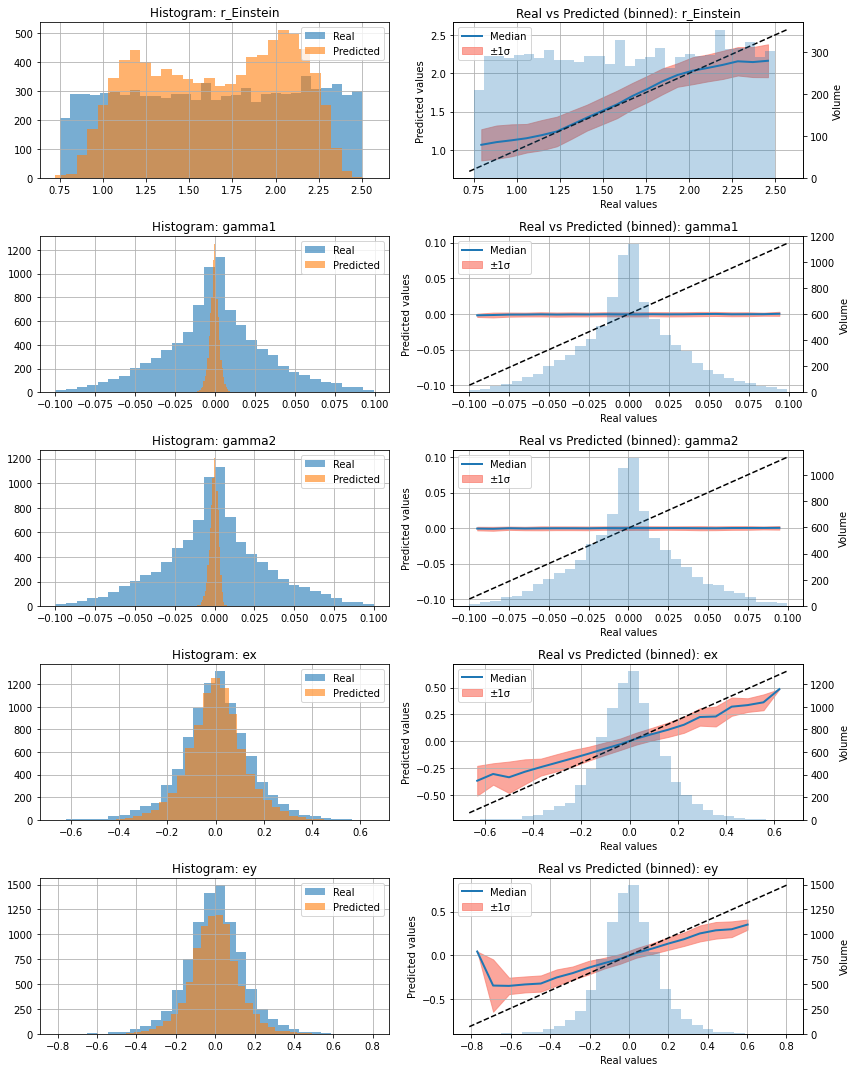

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# # Min/max used for normalization
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # Convert to numpy
# y_true = targets.numpy()
# y_pred = preds.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * (df_max - df_min) + df_min
# y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(12, 15))

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(5, 2, 2*i + 1)
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted")
    plt.title(f"Histogram: {param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(5, 2, 2*i + 2)
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        label="±1σ"
    )
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted (binned): {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/BNN_predictions_arcsinh_images_3.png", dpi=300, bbox_inches="tight")
plt.show()


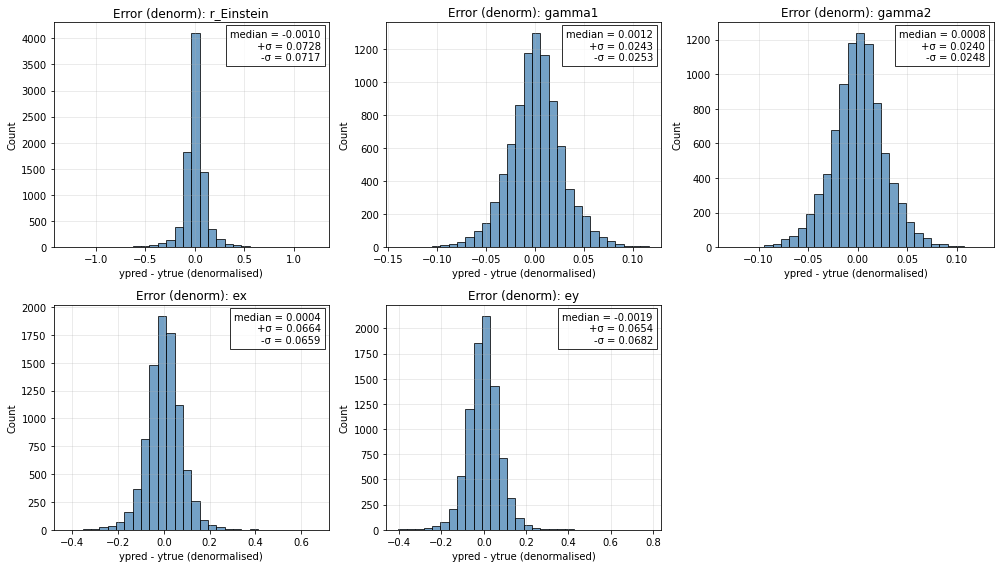

In [38]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Min/max used for normalization ---
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
# scale = df_max - df_min   # range for each parameter

# # --- Convert to numpy ---
# y_true = targets.numpy()
# y_pred = preds.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * scale + df_min
# y_pred_denorm = y_pred * scale + df_min

# # --- Compute denormalised errors ---
# error_denorm = y_pred_denorm - y_true_denorm

# # --- Asymmetric statistics ---
# medians = np.median(error_denorm, axis=0)
# p16 = np.percentile(error_denorm, 16, axis=0)
# p84 = np.percentile(error_denorm, 84, axis=0)

# sigma_minus = medians - p16
# sigma_plus  = p84 - medians

# param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# # --- Plot ---
# plt.figure(figsize=(14, 8))

# for i in range(error_denorm.shape[1]):
#     plt.subplot(2, 3, i+1)
#     plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
#              color="steelblue", edgecolor="black")
#     plt.title(f"Error (denorm): {param_names[i]}")
#     plt.xlabel("ypred - ytrue (denormalised)")
#     plt.ylabel("Count")
#     plt.grid(alpha=0.3)

#     # --- Add text box with denormalised stats ---
#     text = (
#         f"median = {medians[i]:.4f}\n"
#         f"+σ = {sigma_plus[i]:.4f}\n"
#         f"-σ = {sigma_minus[i]:.4f}"
#     )

#     plt.text(
#         0.97, 0.97, text,
#         transform=plt.gca().transAxes,
#         fontsize=10,
#         ha="right", va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
#     )

# plt.tight_layout()
# plt.show()


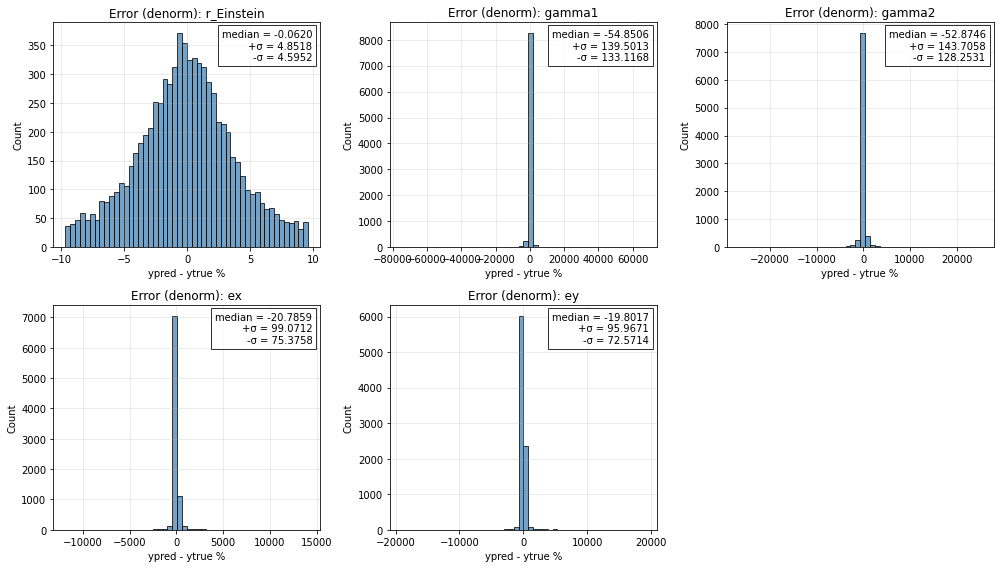

In [39]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Min/max used for normalization ---
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
# scale = df_max - df_min   # range for each parameter

# # --- Convert to numpy ---
# y_true = targets.numpy()
# y_pred = preds.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * scale + df_min
# y_pred_denorm = y_pred * scale + df_min

# # --- Compute denormalised errors ---
# error_denorm = (y_pred_denorm - y_true_denorm)/y_true_denorm * 100

# # --- Asymmetric statistics ---
# medians = np.median(error_denorm, axis=0)
# p16 = np.percentile(error_denorm, 16, axis=0)
# p84 = np.percentile(error_denorm, 84, axis=0)

# sigma_minus = medians - p16
# sigma_plus  = p84 - medians

# param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# # --- Plot ---
# plt.figure(figsize=(14, 8))

# for i in range(error_denorm.shape[1]):
#     plt.subplot(2, 3, i+1)
#     sigma = np.std(error_denorm[:, i])  # or use a predefined sigma value
#     filtered = error_denorm[:, i][(error_denorm[:, i] >= -sigma) & (error_denorm[:, i] <= sigma)]

#     plt.hist(filtered, bins=50, alpha=0.75,
#              color="steelblue", edgecolor="black")
#     plt.title(f"Error (denorm): {param_names[i]}")
#     plt.xlabel("ypred - ytrue %")
#     plt.ylabel("Count")
#     plt.grid(alpha=0.3)

#     # --- Add text box with denormalised stats ---
#     text = (
#         f"median = {medians[i]:.4f}\n"
#         f"+σ = {sigma_plus[i]:.4f}\n"
#         f"-σ = {sigma_minus[i]:.4f}"
#     )

#     plt.text(
#         0.97, 0.97, text,
#         transform=plt.gca().transAxes,
#         fontsize=10,
#         ha="right", va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
#     )

# plt.tight_layout()
# plt.show()


In [40]:
# import numpy as np

# combined = np.concatenate([y_pred_denorm, y_true_denorm], axis=1)
# print(combined.shape)  # Should output (8000, 10)


(8746, 10)


In [41]:
# dg = pd.DataFrame(combined)
# dg.columns = ["r_Einstein", "gamma1", "gamma2", "ex", "ey", "r_Einstein_t", "gamma1_t", "gamma2_t", "ex_t", "ey_t"]

In [42]:
# names = ['e_einstein', 'e_gamma1', 'e_gamma2', 'e_ex', 'e_ey']
# for i in range(5):
#     dg[names[i]] = (dg.iloc[:,i] - dg.iloc[:,i+5])/dg.iloc[:,i+5] * 100


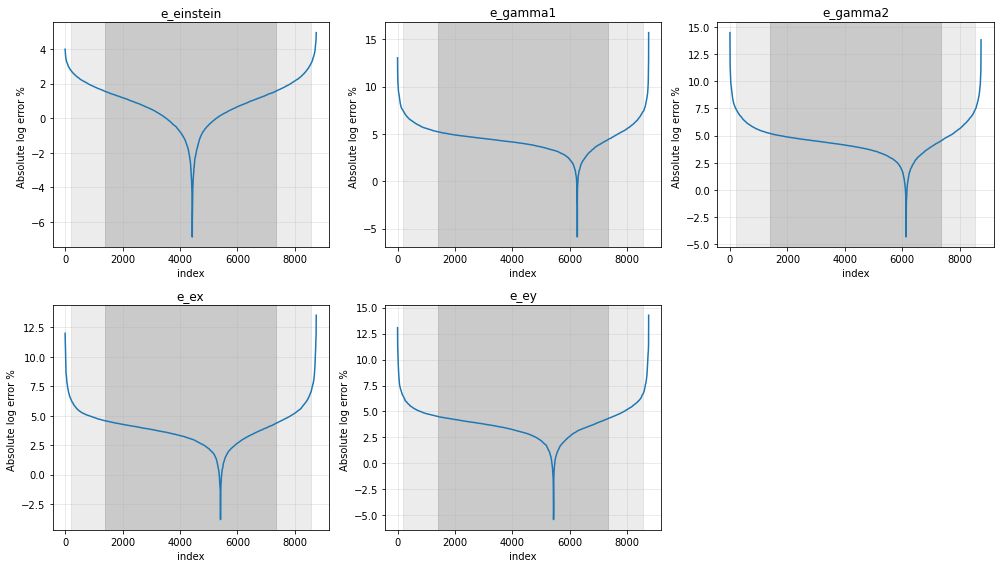

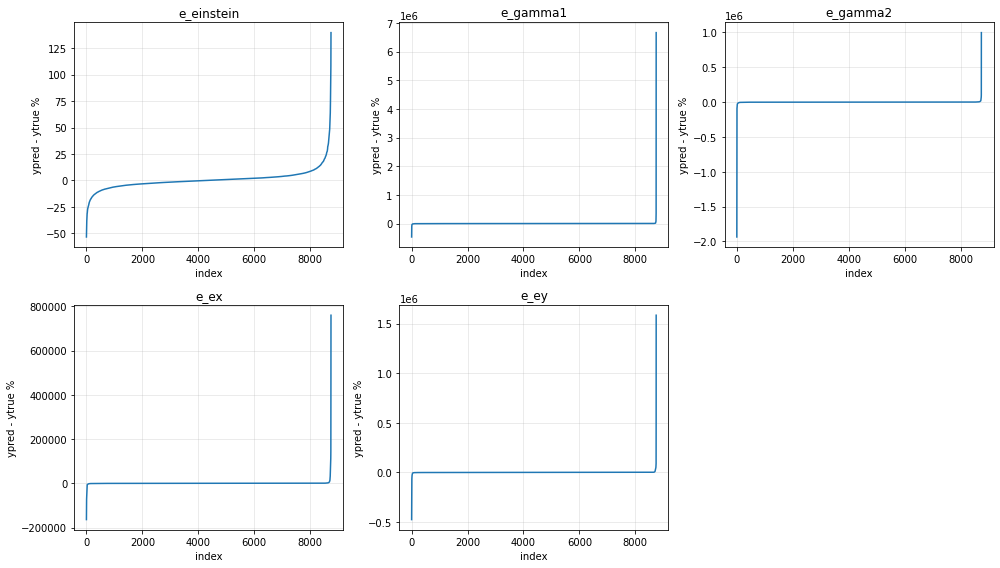

In [48]:
# plt.figure(figsize = (14,8))

# medians = np.median(dg[names], axis=0)
# p16 = np.percentile(dg[names], 16, axis=0)
# p84 = np.percentile(dg[names], 84, axis=0)

# p22 = np.percentile(dg[names], 2.2, axis=0)
# p97 = np.percentile(dg[names], 84, axis=0)

# sigma_minus = medians - p16
# sigma_plus  = p84 - medians


# for i in range(5):
#     plt.subplot(2,3, i+1)
#     plt.plot(np.log(abs(dg[names[i]].sort_values().reset_index()[names[i]])))
#     sigma1 = 0.16 * len(dg)
#     sigma2 = 0.02275 * len(dg)
#     plt.axhspan(sigma_minus[i], sigma_plus[i], color='gray', alpha=0.3)
#     plt.axhspan(sigma2, len(dg) - sigma2, color='gray', alpha=0.15)
# #     plt.axvline(x=sigma1, color='red', linestyle='--', linewidth=2, label= '16 percentile')
# #     plt.axvline(x=sigma2, color='red', linestyle='--', linewidth=2, label= '84 percentile')
#     plt.grid()
#     plt.title(names[i])
#     plt.ylabel("Absolute log error % ")
#     plt.xlabel("index")
#     plt.grid(alpha=0.3)
    
#     text = (
#         f"median = {medians[i]:.4f}\n"
#         f"+σ = {sigma_plus[i]:.4f}\n"
#         f"-σ = {sigma_minus[i]:.4f}"
#     )

#     plt.text(
#         0.97, 0.97, text,
#         transform=plt.gca().transAxes,
#         fontsize=10,
#         ha="right", va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
#     )
# plt.tight_layout()
# plt.show()

# plt.figure(figsize = (14,8))
# for i in range(5):
#     plt.subplot(2,3, i+1)
#     plt.plot(dg[names[i]].sort_values().reset_index()[names[i]])
#     plt.grid()
#     plt.title(names[i])
#     plt.ylabel("ypred - ytrue %")
#     plt.xlabel("index")
#     plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()



In [79]:
np.log(120)

4.787491742782046

In [53]:
# from IPython.display import Image

# Image("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnetmini.png")